# Planck's Constant Arduino Data Analysis



## Initialization

In [2]:
import plotly.express as px
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy as sci

## Circuit Diagrams and Componants

To complete this expermient you will need:

- x1 Microcontroller (eg:Arduino Nano)
- x1 Signal Generator
- x1 Breadboard
- Resitors (220Ω)
- Wires

### Diagrams


<figure>
  <img src="images/circuit_image.png" alt="Circuit Drawing" width="600" height="500">
  <figcaption>Fig.1 Circuit Drawing</figcaption>
</figure>

## Maths

## Code

## Single LED Data Analysis

### Red LED Data Analysis 🔴

In [3]:
redData = pd.read_csv('RealData/redLEDData.csv').drop_duplicates()
redWavelength=631E-9
print(redData.count())
fig = px.scatter(
    redData,
    x="Voltage (V)",
    y="Current (mA)",
    title="Red LED I-V GRAPH λ = 631nm ",
    color_discrete_sequence=['#EF553B']
)
fig.show()


Current (mA)    181
Voltage (V)     181
dtype: int64


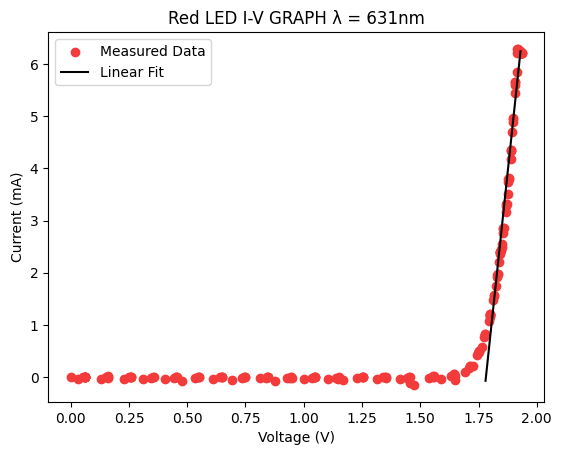

-----------------------------------------------
Linear Region Regression Line: y = 42.10631914965472x + -75.01936667014569
Voltage (V) 1.7816652745995456
Approximate Value of h: 6.008210854301416e-34 , 9.32%
-----------------------------------------------


In [4]:
linearRegionValueLower = 1.78
linearRegionValueUpper = 1.93
linear = redData[
    (redData["Voltage (V)"] > linearRegionValueLower) &
    (redData["Voltage (V)"] < linearRegionValueUpper)
]

plt.figure()
plt.scatter(
    redData["Voltage (V)"],
    redData["Current (mA)"],
    color="#f33b3b",
    label="Measured Data"
)

plt.title("Red LED I-V GRAPH λ = 631nm")
plt.xlabel("Voltage (V)")
plt.ylabel("Current (mA)")

linear = redData[
    (redData["Voltage (V)"] > linearRegionValueLower) &
    (redData["Voltage (V)"] < linearRegionValueUpper)
]

Rm, Rc = np.polyfit(linear["Voltage (V)"], linear["Current (mA)"], 1)
Rf = sci.constants.c/redWavelength

x_fit = np.linspace(linearRegionValueLower, linearRegionValueUpper, 100)
y_fit = Rm * x_fit +Rc
plt.plot(x_fit, y_fit, color="black", label="Linear Fit")

plt.legend()
plt.show()

print("-----------------------------------------------")
print(f"Linear Region Regression Line: y = {Rm}x + {Rc}")

RedThresholdvoltage = -Rc / Rm
print(f"Voltage (V) {RedThresholdvoltage}")

h = (sci.constants.e * RedThresholdvoltage * redWavelength) / sci.constants.c

percentDiff = (sci.constants.h - h) / sci.constants.h * 100

print(f"Approximate Value of h: {h} , {round(percentDiff,2)}%")
print("-----------------------------------------------")

### Yellow LED Data Analysis 🟡

In [5]:
yellowData = pd.read_csv('RealData/yellowLEDData.csv').drop_duplicates()
yellowWavelength=593E-9
print(yellowData.count())
fig = px.scatter(
    yellowData,
    x="Voltage (V)",
    y="Current (mA)",
    title="Yellow LED I-V GRAPH λ = 593nm ",
    color_discrete_sequence=['#ffcd42']
)
fig.show()

Current (mA)    238
Voltage (V)     238
dtype: int64


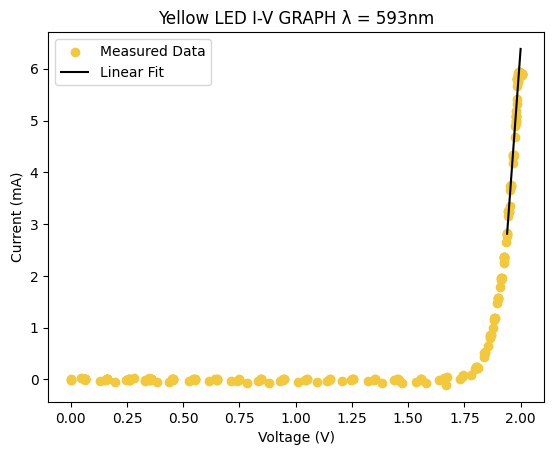

-----------------------------------------------
Linear Region Regression Line: y = 59.47743063680848x + -112.57177753969168
Voltage (V) 1.8926805736968906
Approximate Value of h: 5.998210583223223e-34 , 9.48%
-----------------------------------------------


In [6]:
linearRegionValueLower = 1.94
linearRegionValueUpper = 2.0
linear = yellowData[(yellowData["Voltage (V)"] > linearRegionValueLower) & 
                    (yellowData["Voltage (V)"] < linearRegionValueUpper)]

plt.figure()
plt.scatter(
    yellowData["Voltage (V)"],
    yellowData["Current (mA)"],
    color="#f3c83b",
    label="Measured Data"
)

plt.title("Yellow LED I-V GRAPH λ = 593nm")
plt.xlabel("Voltage (V)")
plt.ylabel("Current (mA)")

# Linear regression
Ym, Yc = np.polyfit(linear["Voltage (V)"], linear["Current (mA)"], 1)


x_fit = np.linspace(linearRegionValueLower, linearRegionValueUpper, 100)
y_fit = Ym * x_fit + Yc
plt.plot(x_fit, y_fit, color="black", label="Linear Fit")

plt.legend()
plt.show()

print("-----------------------------------------------")
print(f"Linear Region Regression Line: y = {Ym}x + {Yc}")

YellowThresholdvoltage = -Yc / Ym
print(f"Voltage (V) {YellowThresholdvoltage}")

h = (sci.constants.e * YellowThresholdvoltage * yellowWavelength) / sci.constants.c

percentDiff = (sci.constants.h - h) / sci.constants.h * 100

print(f"Approximate Value of h: {h} , {round(percentDiff,2)}%")
print("-----------------------------------------------")

### Green LED Data Analysis 🟢

In [7]:
greenData = pd.read_csv('RealData/greenLEDData.csv').drop_duplicates()
greenWavelength=525E-9
print(greenData.count())
fig = px.scatter(
    greenData,
    x="Voltage (V)",
    y="Current (mA)",
    title="Green LED I-V GRAPH λ = 525nm ",
    color_discrete_sequence=["#46c23b"]
)
fig.show()

Current (mA)    246
Voltage (V)     246
dtype: int64


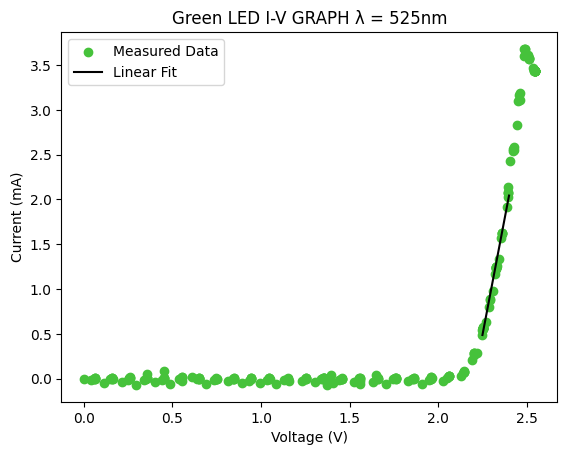

-----------------------------------------------
Linear Region Regression Line: y = 10.377240351482289x + -22.861947836758958
Voltage (V) 2.2030855085180088
Approximate Value of h: 6.181307487518814e-34 , 6.71%
-----------------------------------------------


In [8]:
linearRegionValueLower =2.25
linearRegionValueUpper = 2.4
linear = greenData[(greenData["Voltage (V)"] > linearRegionValueLower) & 
                    (greenData["Voltage (V)"] < linearRegionValueUpper)]

plt.figure()
plt.scatter(
    greenData["Voltage (V)"],
    greenData["Current (mA)"],
    color="#46c23b",
    label="Measured Data"
)

plt.title("Green LED I-V GRAPH λ = 525nm")
plt.xlabel("Voltage (V)")
plt.ylabel("Current (mA)")

Gm, Gc = np.polyfit(linear["Voltage (V)"], linear["Current (mA)"], 1)


x_fit = np.linspace(linearRegionValueLower, linearRegionValueUpper, 100)
y_fit = Gm * x_fit + Gc
plt.plot(x_fit, y_fit, color="black", label="Linear Fit")

plt.legend()
plt.show()

print("-----------------------------------------------")
print(f"Linear Region Regression Line: y = {Gm}x + {Gc}")

GreenThresholdvoltage = -Gc / Gm
print(f"Voltage (V) {GreenThresholdvoltage}")

h = (sci.constants.e * GreenThresholdvoltage * greenWavelength) / sci.constants.c

percentDiff = (sci.constants.h - h) / sci.constants.h * 100

print(f"Approximate Value of h: {h} , {round(percentDiff,2)}%")
print("-----------------------------------------------")

### Blue LED Data Analysis 🔵

In [9]:
blueData = pd.read_csv('RealData/blueLEDData.csv').drop_duplicates()
blueWavelength=467E-9
print(blueData.count())
fig = px.scatter(
    blueData,
    x="Voltage (V)",
    y="Current (mA)",
    title="Blue LED I-V GRAPH λ = 467nm ",
    color_discrete_sequence=["#4995dd"]
)
fig.show()

Current (mA)    226
Voltage (V)     226
dtype: int64


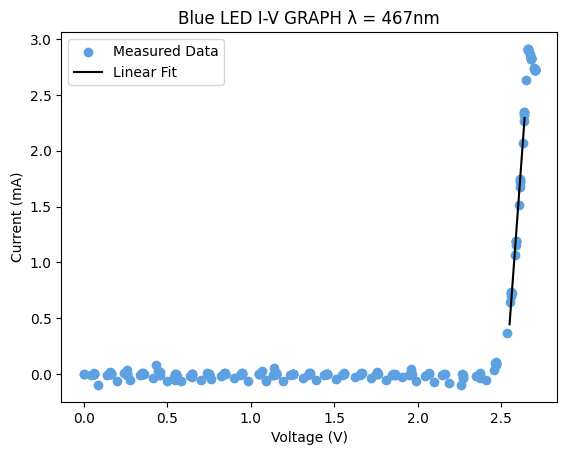

-----------------------------------------------
Linear Region Regression Line: y = 20.535838003700853x + -51.92145813707892
Voltage (V) 2.5283340337862974
Approximate Value of h: 6.310169455455969e-34 , 4.77%
-----------------------------------------------


In [10]:
linearRegionValueLower =2.55
linearRegionValueUpper = 2.64
linear = blueData[(blueData["Voltage (V)"] > linearRegionValueLower) & 
                    (blueData["Voltage (V)"] < linearRegionValueUpper)]

plt.figure()
plt.scatter(
    blueData["Voltage (V)"],
    blueData["Current (mA)"],
    color="#5ea1e0",
    label="Measured Data"
)

plt.title("Blue LED I-V GRAPH λ = 467nm")
plt.xlabel("Voltage (V)")
plt.ylabel("Current (mA)")

Bm, Bc = np.polyfit(linear["Voltage (V)"], linear["Current (mA)"], 1)


x_fit = np.linspace(linearRegionValueLower, linearRegionValueUpper, 100)
y_fit = Bm * x_fit + Bc
plt.plot(x_fit, y_fit, color="black", label="Linear Fit")

plt.legend()
plt.show()

print("-----------------------------------------------")
print(f"Linear Region Regression Line: y = {Bm}x + {Bc}")

BlueThresholdvoltage = -Bc /Bm
print(f"Voltage (V) {BlueThresholdvoltage}")

h = (sci.constants.e * BlueThresholdvoltage * blueWavelength) / sci.constants.c

percentDiff = (sci.constants.h - h) / sci.constants.h * 100

print(f"Approximate Value of h: {h} , {round(percentDiff,2)}%")
print("-----------------------------------------------")

## Threshold Voltage vs Frequency

In [11]:
thresholdVoltages = [RedThresholdvoltage,YellowThresholdvoltage,GreenThresholdvoltage,BlueThresholdvoltage]
frequencies = [(sci.constants.c/redWavelength),(sci.constants.c/yellowWavelength),(sci.constants.c/greenWavelength),(sci.constants.c/blueWavelength)]

fig = px.scatter(
    x=frequencies,
    y=thresholdVoltages,
    title="Threshold Voltage vs Frequency",
    color_discrete_sequence=["#2c2c2c"],
    trendline="ols"
)
fig.show()



slope = px.get_trendline_results(fig).px_fit_results.iloc[0].params[1]

h = slope * sci.constants.e

percent_error = (h - sci.constants.h) / sci.constants.h * 100

print(f"Plancks Constant Final Value: {h}, % error = {percent_error}")

Plancks Constant Final Value: 6.1544403138440114e-34, % error = -7.117791171528548
